In [80]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)


%matplotlib inline
sb.set_style("whitegrid")
plt.style.use("default")


In [81]:

cardiodata = pd.read_csv("cardio_clean-2.csv")
cardiodata.head()

# Feature Engineering
cardiodata["pulse_pressure"]=cardiodata["bp_systolic"]-cardiodata["bp_diastolic"]
cardiodata["bmi_bp"] = cardiodata["bmi"] * cardiodata["bp_systolic"]
cardiodata["age_bp"] = cardiodata["age_years"] * cardiodata["bp_systolic"]
cardiodata["bmi_age"] = cardiodata["bmi"] * cardiodata["age_years"]

#Feature Set
non_clinical_features = [
    "bmi", "age_years", "smoke", "active", "alco", "gender"
]

full_features = [
    "bmi", "age_years", "smoke", "active", "alco", "gender",
    "bp_systolic", "bp_diastolic", "pulse_pressure",
    "cholesterol", "gluc",
    "bmi_bp", "age_bp", "bmi_age"
]

results = []

In [82]:
# -----------------------------
# 1. NON-CLINICAL MODEL
# -----------------------------

X_nc = cardiodata[non_clinical_features]
y = cardiodata["cardio"]

X_train_nc, X_test_nc, y_train, y_test = train_test_split(
    X_nc, y, test_size=0.25, random_state=42, stratify=y
)

print("Non-clinical train/test:", X_train_nc.shape, X_test_nc.shape)

Non-clinical train/test: (49414, 6) (16472, 6)


In [83]:
# Random Forest- Non clinical
rf_nc= RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_nc.fit(X_train_nc, y_train)
rf_nc_pred = rf_nc.predict(X_test_nc)

print("=== Random Forest (Non-Clinical) ===")
print("Accuracy:", accuracy_score(y_test, rf_nc_pred))
print(classification_report(y_test, rf_nc_pred))
acc_list = []

results.append(["Random Forest", "Non-Clinical", acc, auc])

# Feature importance
importance_nc = pd.DataFrame({
    "Feature": X_train_nc.columns,
    "Importance": rf_nc.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Non-Clinical):")
print(importance_nc)



=== Random Forest (Non-Clinical) ===
Accuracy: 0.6253642544924721
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      8341
           1       0.62      0.60      0.61      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472


Feature Importance (Non-Clinical):
     Feature  Importance
1  age_years    0.478990
0        bmi    0.468430
3     active    0.016729
5     gender    0.016685
4       alco    0.009608
2      smoke    0.009557


In [84]:
X_full = cardiodata[full_features]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.25, random_state=42, stratify=y
)

rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
rf_full.fit(X_train_full, y_train)
rf_full_pred = rf_full.predict(X_test_full)

print("\n=== Random Forest (Full Features) ===")
print("Accuracy:", accuracy_score(y_test, rf_full_pred))
print(classification_report(y_test, rf_full_pred))

results.append(["Random Forest", "Full", acc, auc])

importance_full = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": rf_full.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Full Model):")
print(importance_full)



=== Random Forest (Full Features) ===
Accuracy: 0.7370082564351627
              precision    recall  f1-score   support

           0       0.72      0.80      0.75      8341
           1       0.77      0.67      0.72      8131

    accuracy                           0.74     16472
   macro avg       0.74      0.74      0.74     16472
weighted avg       0.74      0.74      0.74     16472


Feature Importance (Full Model):
           Feature  Importance
6      bp_systolic    0.260185
12          age_bp    0.191024
7     bp_diastolic    0.121902
8   pulse_pressure    0.096275
11          bmi_bp    0.092891
13         bmi_age    0.065691
9      cholesterol    0.063829
1        age_years    0.048807
0              bmi    0.033409
10            gluc    0.009123
3           active    0.006582
5           gender    0.004565
2            smoke    0.003242
4             alco    0.002474



=== Logistic Regression (Non-Clinical) ===
Accuracy: 0.6279140359397766
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      8341
           1       0.63      0.61      0.62      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472



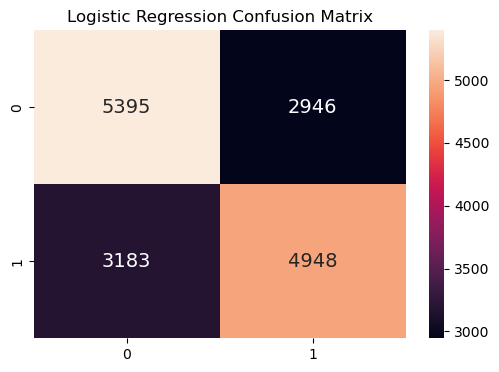

In [85]:
# -----------------------------
# 3. LOGISTIC REGRESSION-Non Clinical
# -----------------------------
scaler_lr = StandardScaler()
X_train_nc_scaled = scaler_lr.fit_transform(X_train_nc)
X_test_nc_scaled = scaler_lr.transform(X_test_nc)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_nc_scaled, y_train)
lr_pred = lr.predict(X_test_nc_scaled)

print("\n=== Logistic Regression (Non-Clinical) ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("Logistic Regression Confusion Matrix")
plt.show()

results.append(["Logistic Regression", "Non-Clinical", acc, auc])




=== Logistic Regression (Full) ===
Accuracy: 0.7306338028169014
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      8341
           1       0.75      0.68      0.71      8131

    accuracy                           0.73     16472
   macro avg       0.73      0.73      0.73     16472
weighted avg       0.73      0.73      0.73     16472



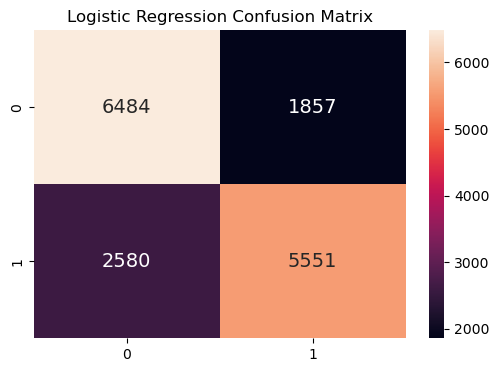

In [86]:
# -----------------------------
# 3. LOGISTIC REGRESSION-FULL
# -----------------------------
scaler_lr = StandardScaler()
X_train_full_scaled = scaler_lr.fit_transform(X_train_full)
X_test_full_scaled = scaler_lr.transform(X_test_full)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_full_scaled, y_train)
lr_pred = lr.predict(X_test_full_scaled)

print("\n=== Logistic Regression (Full) ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("Logistic Regression Confusion Matrix")
plt.show()

results.append(["Logistic Regression", "Full", acc, auc])



=== KNN (Non-Clinical) ===
Accuracy: 0.574125789218067
              precision    recall  f1-score   support

           0       0.58      0.59      0.58      8341
           1       0.57      0.56      0.57      8131

    accuracy                           0.57     16472
   macro avg       0.57      0.57      0.57     16472
weighted avg       0.57      0.57      0.57     16472



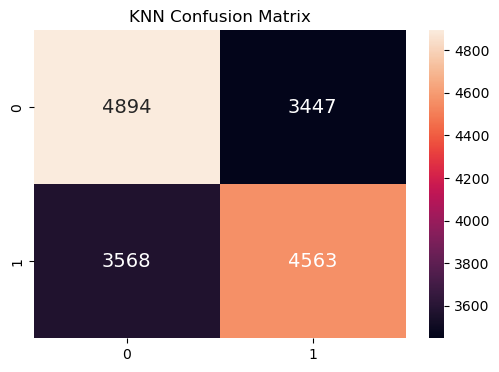

In [87]:
# -----------------------------
# 4. KNN-Non Clinical
# -----------------------------
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_nc)
X_test_knn = scaler_knn.transform(X_test_nc)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)
knn_pred = knn.predict(X_test_knn)

print("\n=== KNN (Non-Clinical) ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("KNN Confusion Matrix")
plt.show()

results.append(["KNN", "Non-Clinical", acc, auc])



=== KNN (Full) ===
k=3, acc=0.6809
k=5, acc=0.6999
k=7, acc=0.7060
k=9, acc=0.7147
k=11, acc=0.7175
              precision    recall  f1-score   support

           0       0.58      0.59      0.58      8341
           1       0.57      0.56      0.57      8131

    accuracy                           0.57     16472
   macro avg       0.57      0.57      0.57     16472
weighted avg       0.57      0.57      0.57     16472



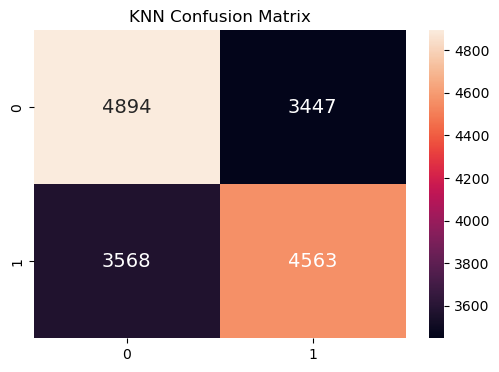

In [88]:

# 4. KNN-Full
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_full)
X_test_knn = scaler_knn.transform(X_test_full)
print("\n=== KNN (Full) ===")

for k in [3,5,7,9,11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    pred = knn.predict(X_test_knn)
    print(f"k={k}, acc={accuracy_score(y_test, pred):.4f}")


print(classification_report(y_test, knn_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("KNN Confusion Matrix")
plt.show()

results.append(["KNN", "Full", acc, auc])


=== XGBoost (Non-Clinical) ===
Accuracy: 0.6287
              precision    recall  f1-score   support

           0       0.63      0.64      0.63      8341
           1       0.62      0.62      0.62      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472

ROC-AUC: 0.6765


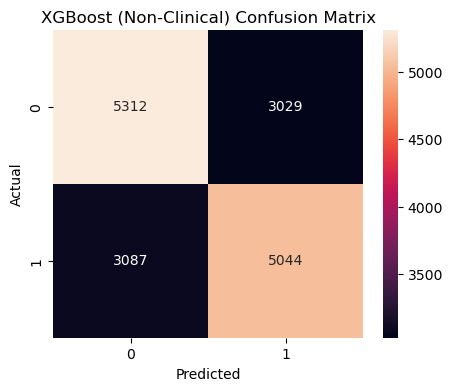

<Figure size 800x600 with 0 Axes>

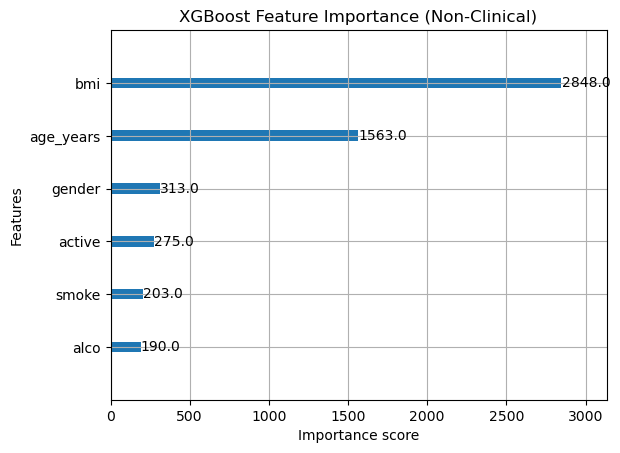

In [89]:
#xgboost-nc

xgb_nc = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

xgb_nc.fit(X_train_nc, y_train)
xgb_nc_pred = xgb_nc.predict(X_test_nc)
xgb_nc_prob = xgb_nc.predict_proba(X_test_nc)[:, 1]

print("\n=== XGBoost (Non-Clinical) ===")

# Accuracy
acc = accuracy_score(y_test, xgb_nc_pred)
print("Accuracy:", round(acc, 4))

# Classification report
print(classification_report(y_test, xgb_nc_pred))

# ROC-AUC
auc = roc_auc_score(y_test, xgb_nc_prob)
print("ROC-AUC:", round(auc, 4))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_nc_pred)
plt.figure(figsize=(5, 4))
sb.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost (Non-Clinical) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
plt.figure(figsize=(8, 6))
xgb.plot_importance(xgb_nc, max_num_features=10)
plt.title("XGBoost Feature Importance (Non-Clinical)")
plt.show()

results.append(["XGBoost", "Non-Clinical", acc, auc])


=== XGBoost (FULL) ===
Accuracy: 0.738
              precision    recall  f1-score   support

           0       0.72      0.80      0.75      8341
           1       0.76      0.68      0.72      8131

    accuracy                           0.74     16472
   macro avg       0.74      0.74      0.74     16472
weighted avg       0.74      0.74      0.74     16472

ROC-AUC: 0.8005


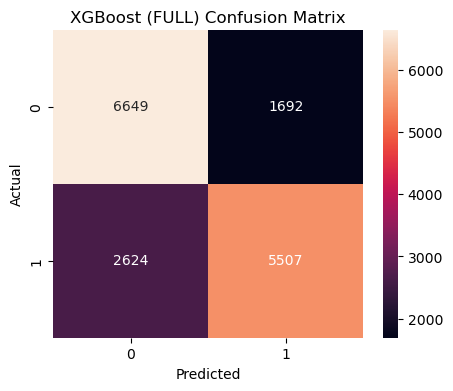

<Figure size 800x600 with 0 Axes>

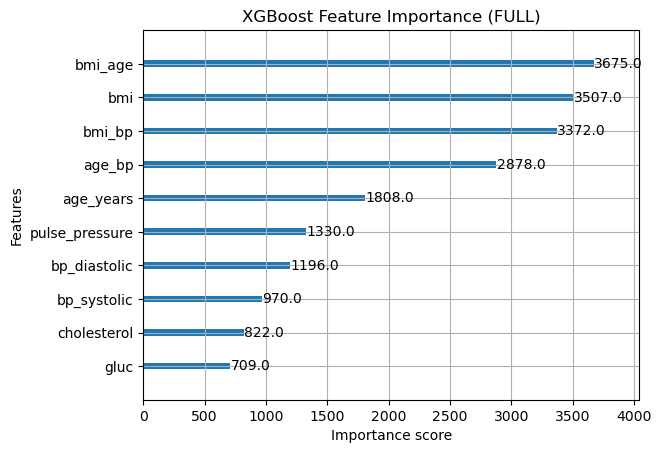

In [90]:
xgb_full = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

xgb_full.fit(X_train_full, y_train)
xgb_full_pred = xgb_full.predict(X_test_full)
xgb_full_prob = xgb_full.predict_proba(X_test_full)[:, 1]

print("\n=== XGBoost (FULL) ===")

# Accuracy
acc = accuracy_score(y_test, xgb_full_pred)
print("Accuracy:", round(acc, 4))

# Classification report
print(classification_report(y_test, xgb_full_pred))

# ROC-AUC
auc = roc_auc_score(y_test, xgb_full_prob)
print("ROC-AUC:", round(auc, 4))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_full_pred)
plt.figure(figsize=(5, 4))
sb.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost (FULL) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
plt.figure(figsize=(8, 6))
xgb.plot_importance(xgb_full, max_num_features=10)
plt.title("XGBoost Feature Importance (FULL)")
plt.show()

results.append(["XGBoost", "Full", acc, auc])


=== Age Group Comparison ===

Top features for 45-54:
           Feature  Importance
6      bp_systolic    0.296911
12          age_bp    0.192481
7     bp_diastolic    0.138900
11          bmi_bp    0.101079
8   pulse_pressure    0.088859

Top features for 55-64:
           Feature  Importance
12          age_bp    0.259717
6      bp_systolic    0.207922
11          bmi_bp    0.099422
7     bp_diastolic    0.089665
8   pulse_pressure    0.086081

Top features for 35-44:
           Feature  Importance
6      bp_systolic    0.252688
12          age_bp    0.237790
7     bp_diastolic    0.137157
11          bmi_bp    0.109437
8   pulse_pressure    0.066634

Age Group Accuracy Comparison:
  Age Group  Accuracy
0     45-54  0.740457
1     55-64  0.670762
2     35-44  0.808893


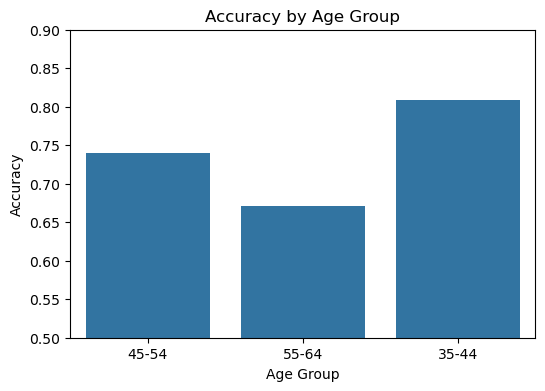

In [91]:
print("\n=== Age Group Comparison ===")
age_group_results = []

for group in cardiodata["age_cat"].dropna().unique():
    group_df = cardiodata[cardiodata["age_cat"] == group]

    X_group = group_df[full_features]
    y_group = group_df["cardio"]

    if len(group_df) < 50:
        continue

    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_group, y_group,
        test_size=0.25,
        random_state=42,
        stratify=y_group
    )

    model_g = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    )

    model_g.fit(X_train_g, y_train_g)
    pred_g = model_g.predict(X_test_g)
    acc_g = accuracy_score(y_test_g, pred_g)

    age_group_results.append([group, acc_g])

    importance_g = pd.DataFrame({
        "Feature": X_group.columns,
        "Importance": model_g.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print(f"\nTop features for {group}:")
    print(importance_g.head(5))

age_group_results_df = pd.DataFrame(age_group_results, columns=["Age Group", "Accuracy"])
print("\nAge Group Accuracy Comparison:")
print(age_group_results_df)

plt.figure(figsize=(6, 4))
sb.barplot(data=age_group_results_df, x="Age Group", y="Accuracy")
plt.title("Accuracy by Age Group")
plt.ylim(0.5, 0.9)
plt.show()


=== Risk Score Sample ===
       Predicted_Prob Risk_Level
53649        0.540871     Medium
22735        0.298736        Low
5290         0.823345       High
43           0.357546     Medium
35866        0.087086        Low

Risk distribution:
Risk_Level
Medium    6095
Low       5339
High      5038
Name: count, dtype: int64


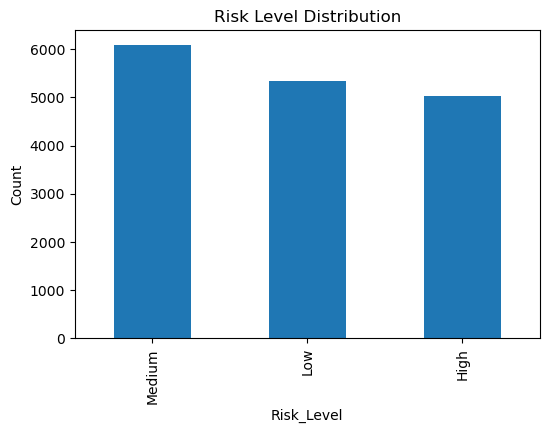

In [92]:
best_probs = xgb_full.predict_proba(X_test_full)[:, 1]

def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

risk_labels = [risk_level(p) for p in best_probs]

risk_df = X_test_full.copy()
risk_df["Actual"] = y_test.values
risk_df["Predicted_Prob"] = best_probs
risk_df["Risk_Level"] = risk_labels

print("\n=== Risk Score Sample ===")
print(risk_df[["Predicted_Prob", "Risk_Level"]].head())

print("\nRisk distribution:")
print(risk_df["Risk_Level"].value_counts())

plt.figure(figsize=(6, 4))
risk_df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.ylabel("Count")
plt.show()